In [18]:
from dptb.postprocess.elec_struc_cal import ElecStruCal
from dptb.data import AtomicDataDict
from dptb.nn.dftbsk import DFTBSK
from ase.io import read
import torch
from dptb.nn.dftb.dftb_scc import DFTBSCC
from dptb.utils.tools import j_loader
from dptb.utils.make_kpoints  import abacus_kpath

In [19]:
# sk_path = "slakos"
sk_path = "./slakos"
basis = {'B':['2s','2p'],"N":["2s","2p"]}
overlap = True

struct = './data/struct.vasp'
# struct = './data/struct_iso.xyz'
AtomicData_options = {"r_max": {'B': 6.349479778742587, 'N': 5.366822193937187}}
kmeshgrid = [20, 20, 1]  # Example k-point mesh grid
nel_atom = {'B': 3, 'N': 5}



dftbscc = DFTBSCC(  basis = basis, 
                    sk_path = sk_path,
                    overlap = True,
                    smooth_ski = True,)

dftbscc.run_iters(data = struct,
                nel_atom = nel_atom,
                kmeshgrid = kmeshgrid,
                kgamma_center = True,
                krotational_symmetry = False,
                ktime_inversion_symmetry = True,
                AtomicData_options = AtomicData_options,
                mix_rate = 0.25,
                max_iter = 1000,
                Temp = 0.1,
                smearing_method = 'Fermi-Dirac')

Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'B': 6.349479778742587, 'N': 5.366822193937187}
This is very dangerous, please make sure you know what you are doing.


In [20]:
dftbscc.scc_shift_energy

tensor(0.0445, dtype=torch.float64)

In [21]:
dftbscc.elec_H0_bandE

tensor([-104.6111], dtype=torch.float64)

In [22]:
dftbscc.scc_shift

tensor([0.6619, 0.2670], dtype=torch.float64)

In [23]:
dftbscc.elec_totE

tensor([-104.5666], dtype=torch.float64)

In [24]:
dftbscc.mulliken.delta_charge

array([ 0.22530016, -0.22530016])

In [25]:
# generate k-path
struct = './data/struct.vasp'
structase = read(struct, format='vasp')

jdata = j_loader("./band.json")
kpath_kwargs = jdata["task_options"]
kpath = kpath_kwargs['kpath']
labels = kpath_kwargs['klabels']
klist, xlist, high_sym_kpoints  = abacus_kpath(structase=structase, kpath=kpath) 

dftbscc.data[AtomicDataDict.KPOINT_KEY] = \
            torch.nested.as_nested_tensor([torch.as_tensor(klist, 
                                                           dtype = dftbscc.model.dtype, 
                                                           device = dftbscc.model.device)])

In [26]:
dftbscc.data = dftbscc.model(dftbscc.data)

dftbscc.data = dftbscc.h2k(dftbscc.data)
dftbscc.data = dftbscc.s2k(dftbscc.data)

In [12]:
scc_HK = dftbscc.cal_scc_hk(data=dftbscc.data, 
                            per_atom_indices=dftbscc.mulliken.per_atom_indices,
                            scc_shift=dftbscc.scc_shift)
H_converged = dftbscc.data[AtomicDataDict.HAMILTONIAN_KEY].clone() + scc_HK

In [13]:
eigvecs, eigvals = [],[]

if dftbscc.overlap:
    chklowt = torch.linalg.cholesky(dftbscc.data[AtomicDataDict.OVERLAP_KEY])
    chklowtinv = torch.linalg.inv(chklowt)
    H_eff = (chklowtinv @ H_converged @ torch.transpose(chklowtinv,dim0=1,dim1=2).conj())
else:
    H_eff = H_converged
eigval, eigvec = torch.linalg.eigh(H_eff)
eigvecs.append(torch.transpose(torch.transpose(chklowtinv,dim0=1,dim1=2).conj() @ eigvec,dim0=1,dim1=2))
eigvals.append(eigval)

# Update eigenvalues and eigenvectors in the data dictionary
dftbscc.data[AtomicDataDict.ENERGY_EIGENVALUE_KEY] = torch.nested.as_nested_tensor([torch.cat(eigvals, dim=0)])
dftbscc.data[AtomicDataDict.EIGENVECTOR_KEY] = torch.cat(eigvecs, dim=0)

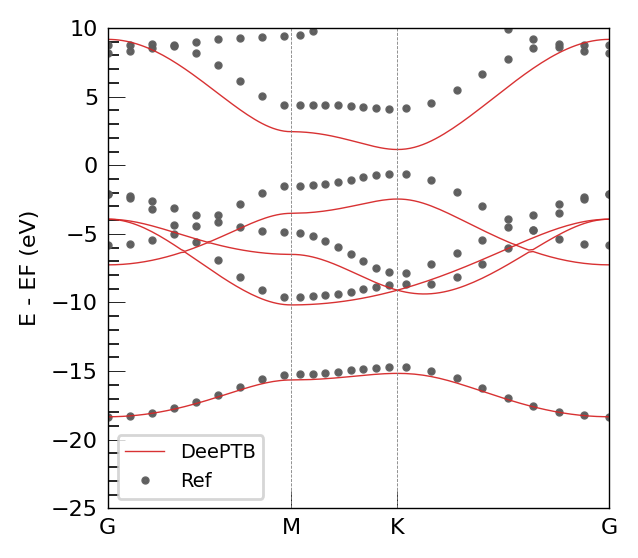

In [16]:
from dptb.postprocess.bandstructure.band import Band

eigenstatus = { 'klist': klist,
                'xlist': xlist,
                'high_sym_kpoints': high_sym_kpoints,
                'labels': labels,
                'eigenvalues': dftbscc.data[AtomicDataDict.ENERGY_EIGENVALUE_KEY][0].detach().cpu().numpy(),
                'E_fermi': -3.6}

bcal = Band(model=dftbscc.model, results_path=None, device='cpu')
bcal.eigenstatus = eigenstatus
bcal.band_plot(ref_band = kpath_kwargs["ref_band"],
               E_fermi = -3.6,
               emin = -25,
               emax = 10)


Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'B': 6.349479778742587, 'N': 5.366822193937187}
This is very dangerous, please make sure you know what you are doing.


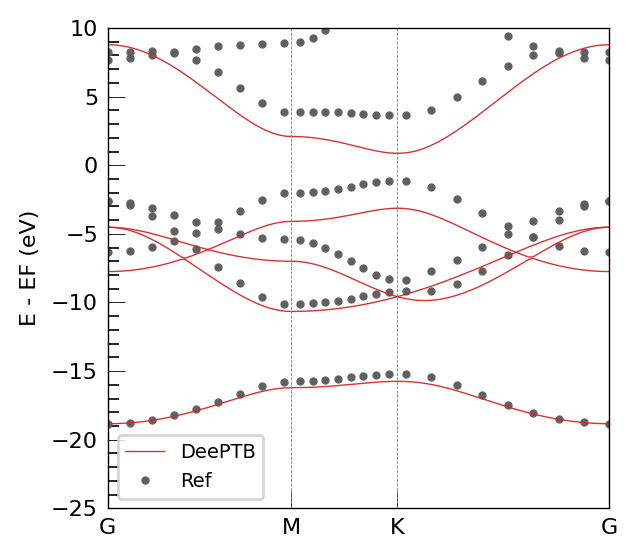

In [17]:
model = DFTBSK(basis=basis, 
                 skdata=sk_path,
                 overlap=overlap)
dftb_elec = ElecStruCal(model=model, device='cpu', eig_method='eigh')
data_noscc, eigs_noscc =  dftb_elec.get_eigs(data=struct, 
                                 klist=klist, 
                                 AtomicData_options=AtomicData_options)

eigenstatus_noscc = { 'klist': klist,
                'xlist': xlist,
                'high_sym_kpoints': high_sym_kpoints,
                'labels': labels,
                'eigenvalues': data_noscc[AtomicDataDict.ENERGY_EIGENVALUE_KEY][0].detach().cpu().numpy(),
                'E_fermi': -3.6}

bcal_noscc = Band(model=model, results_path=None, device='cpu')
bcal_noscc.eigenstatus = eigenstatus_noscc
bcal_noscc.band_plot(ref_band = kpath_kwargs["ref_band"],
                     E_fermi = -3.6,
                     emin = -25,
                     emax = 10)
